# Analyze your own session — start here

This is the practical starting point for running **miniCNMFe** on *your own*
miniscope recording, end to end:

> motion-correct → pick detection parameters → extract → inspect → save

It is a **template**: set the paths and a few numbers in the config cell below,
then run the notebook top to bottom. It defaults to the bundled demo session so
it runs out of the box — replace `SESSION` with your own data.

- Want to understand each stage in depth? Work through notebooks **01–04**, which
  teach one stage each on the bundled demo movies (01 load & motion-correct,
  02 tuning, 03 extraction, 04 advanced/production knobs).
- Real recordings have **no ground truth**, so here we judge quality *by eye*:
  the CORR/PNR maps, footprints overlaid on the correlation image, and the traces.

If you would rather not pick parameters by hand at all, run the automated tuner
(`python tune.py <session>`, or the `/tune-session` skill) — see notebook 02 and
`docs/tuning/`.

## 1. Configure — point this at your session

In [1]:
from pathlib import Path

def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "minicnmfe").exists():
            return cand
    return here
REPO = find_repo_root()

# --- EDIT THESE -------------------------------------------------------------
# Your session. One of:
#   * a FOLDER of numbered AVIs   (0.avi, 1.avi, ... — the usual miniscope output)
#   * a single .avi / .mp4 file
#   * an already motion-corrected  mc.zarr
# The default points at the bundled demo movie so the notebook runs out of the box
# (anchored to the repo root, so it works whatever directory the kernel starts in).
# Replace with YOUR session — an absolute path is simplest.
SESSION    = REPO / "demo_movies" / "realistic_medium.avi"   # <-- replace with YOUR session
OUTPUT_DIR = REPO / "my_session_out"                          # mc.zarr + results land here

# Indicator + acquisition — sets the calcium-dynamics prior (strongly recommended).
# Single-AP decay time (ms): jGCaMP8f ~70, GCaMP6f ~140, jGCaMP8m ~180,
#                            jGCaMP8s ~350, GCaMP6s/7s ~1000.
DECAY_TIME_MS = 180
FRAME_RATE_HZ = 20

# Detection — refine SIGMA / MIN_CORR / MIN_PNR in step 3 from the CORR/PNR maps.
SIGMA    = 4.0     # neuron *radius* in pixels (eyeball a few somata)
MIN_CORR = 0.8     # lower -> more (but noisier) detections
MIN_PNR  = 8.0     # lower -> more (but noisier) detections

N_JOBS = -1        # -1 = all CPU cores
# ----------------------------------------------------------------------------
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("session   :", SESSION)
print("output dir:", OUTPUT_DIR)

session   : /home/fs539/code/simpler_cnmfe/demo_movies/realistic_medium.avi
output dir: /home/fs539/code/simpler_cnmfe/my_session_out


## 2. Motion-correct (or load an already-corrected movie)

The cell below handles all three input kinds:

- **AVI folder** → fused decode + rigid motion correction in one pass
  (`fit_mc_from_avis`), writing only `mc.zarr`.
- **single AVI/MP4** → convert to zarr, then motion-correct (`fit_mc`).
- **`mc.zarr`** → just open it (already corrected).

`mc` ends up as a lazy zarr handle to the corrected movie.

In [2]:
import numpy as np
from minicnmfe.io import avi_to_zarr, open_zarr
from minicnmfe.pipeline import CNMFe, CNMFeParams

# Motion-correction params. mc_gSig_filt (the 1p high-pass) tracks the neuron scale.
mc_params = CNMFeParams(max_shift=(20, 20), upsample_factor=10, mc_n_iter=1,
                        mc_gSig_filt=SIGMA, n_jobs=N_JOBS)

mc_model = None                                  # holds shifts when we run MC
if SESSION.suffix == ".zarr":
    mc = open_zarr(SESSION)                      # already motion-corrected
elif SESSION.is_dir():
    mc_model = CNMFe(mc_params)
    mc = mc_model.fit_mc_from_avis(SESSION, output_dir=OUTPUT_DIR, skip_if_exists=True)
else:                                            # single AVI / MP4
    raw = OUTPUT_DIR / (SESSION.stem + ".zarr")
    if not raw.exists():
        avi_to_zarr(SESSION, raw, chunk_t=200, grayscale=True, dtype="uint8")
    mc_model = CNMFe(mc_params)
    mc = mc_model.fit_mc(open_zarr(raw), output_dir=OUTPUT_DIR)

T, H, W = mc.shape
print(f"corrected movie: {mc.shape}   (~{T * H * W * 4 / 1e9:.1f} GB if fully loaded)")

Sharpening template on a 600-frame in-RAM sample (<= 10 alignment rounds)...


Rigid iteration 1/1


MC pass:   0%|          | 0/3 [00:00<?, ?it/s]

MC pass:  67%|██████▋   | 2/3 [00:00<00:00, 10.79it/s]

MC pass: 100%|██████████| 3/3 [00:00<00:00,  9.90it/s]

  MC pass: 600 frames (read+MC+write) in 0.3s (1971 fps)
corrected movie: (600, 128, 128)   (~0.0 GB if fully loaded)


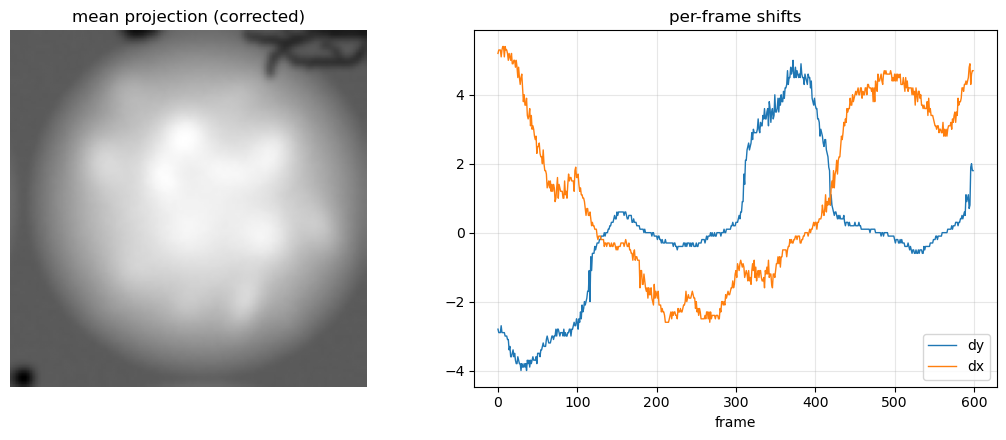

In [3]:
import matplotlib.pyplot as plt

# Streamed mean projection (RAM-bounded) + the per-frame shift trajectory if we ran MC.
def mean_projection(z, batch=500):
    acc = np.zeros(z.shape[1:], dtype=np.float64)
    for s in range(0, z.shape[0], batch):
        acc += np.asarray(z[s:s + batch], dtype=np.float64).sum(0)
    return (acc / z.shape[0]).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(mean_projection(mc), cmap="gray")
axes[0].set_title("mean projection (corrected)"); axes[0].axis("off")
if mc_model is not None and getattr(mc_model, "shifts", None) is not None:
    axes[1].plot(mc_model.shifts[:, 0], lw=1, label="dy")
    axes[1].plot(mc_model.shifts[:, 1], lw=1, label="dx")
    axes[1].set_title("per-frame shifts"); axes[1].set_xlabel("frame")
    axes[1].legend(); axes[1].grid(alpha=0.3)
else:
    axes[1].axis("off"); axes[1].set_title("(shifts unavailable — input was mc.zarr)")
plt.tight_layout(); plt.show()

## 3. Pick detection parameters from the CORR / PNR maps

Two summary images tell you where the cells are and let you set thresholds from
the data instead of guessing:

- **CORR** — how correlated each pixel is with its neighbours (somata light up).
- **PNR** — how tall each pixel's biggest transient is vs its noise.

Set **`SIGMA`** ≈ the neuron *radius*; set **`MIN_CORR` / `MIN_PNR`** just below the
bright cluster in the scatter. (For a hands-off recommendation, run
`python tune.py <session>` — see notebook 02.)

CORR range [-0.00, 1.00]   PNR range [2.2, 20.3]


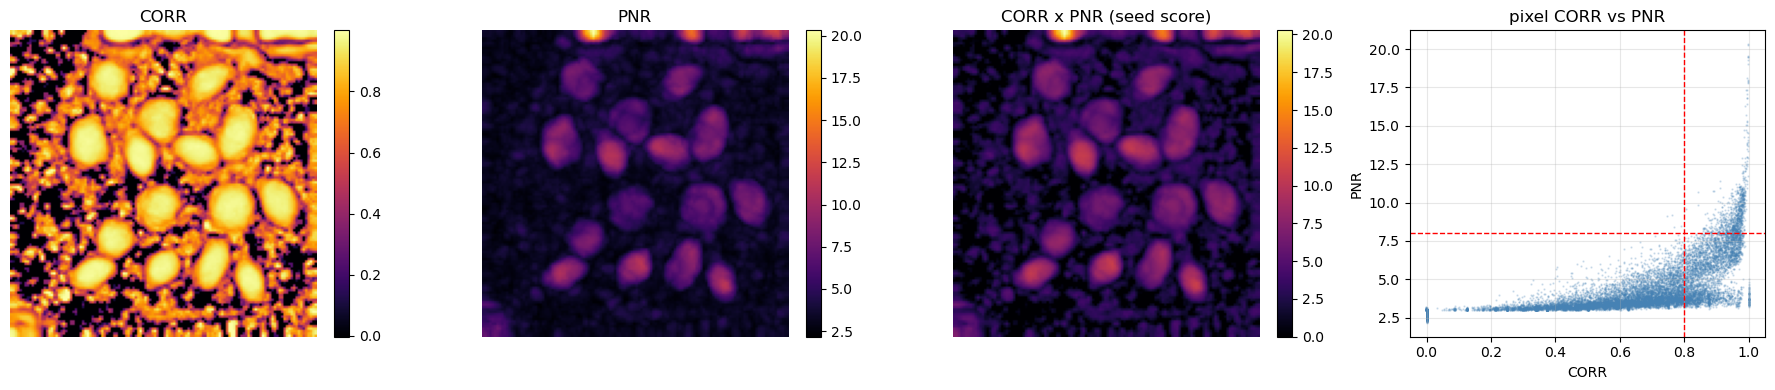

Red dashed lines = your current MIN_CORR / MIN_PNR. Move them just below the bright cluster.


In [4]:
from minicnmfe.preprocess import correlation_pnr

# Compute the maps on a time sample (fast, representative).
n_sample = min(T, 3000)
mc_sample = np.asarray(mc[:n_sample], dtype=np.float32)
cn, pnr = correlation_pnr(mc_sample, sigma=SIGMA, center_psf=True,
                          n_jobs=N_JOBS, stride=max(1, n_sample // 1000))
print(f"CORR range [{cn.min():.2f}, {cn.max():.2f}]   PNR range [{pnr.min():.1f}, {pnr.max():.1f}]")

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, img, ttl in zip(ax[:3], [cn, pnr, cn * pnr], ["CORR", "PNR", "CORR x PNR (seed score)"]):
    im = a.imshow(img, cmap="inferno"); a.set_title(ttl); a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046)
ax[3].scatter(cn.ravel(), pnr.ravel(), s=0.5, alpha=0.2, c="steelblue")
ax[3].axvline(MIN_CORR, color="r", ls="--", lw=1); ax[3].axhline(MIN_PNR, color="r", ls="--", lw=1)
ax[3].set_xlabel("CORR"); ax[3].set_ylabel("PNR"); ax[3].set_title("pixel CORR vs PNR")
ax[3].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Red dashed lines = your current MIN_CORR / MIN_PNR. Move them just below the bright cluster.")

## 4. Extract

Runs the full pipeline with your parameters. Small movies load into RAM; large
ones (60k+ frames) stream from disk automatically via `output_dir=` — see
notebook 03 and `docs/getting-started/` for the streaming details.

On long or drifting recordings, consider `global_bg_rank=1` (a rank-1 global
background that absorbs slow drift/photobleaching) — see notebook 04.

In [5]:
params = CNMFeParams(
    sigma=SIGMA, min_corr=MIN_CORR, min_pnr=MIN_PNR,
    decay_time_ms=DECAY_TIME_MS, frame_rate_hz=FRAME_RATE_HZ,
    n_iter_main=2, n_jobs=N_JOBS,
    # global_bg_rank=1,          # <- long / drifting recordings (see notebook 04)
)
model = CNMFe(params)

if T * H * W * 4 / 1e9 < 8:                       # fits comfortably in RAM
    model.fit(np.asarray(mc, dtype=np.float32), do_motion_correction=False)
else:                                             # stream (RAM bounded, independent of T)
    model.fit(mc, do_motion_correction=False, output_dir=OUTPUT_DIR)

K = int(model.A.shape[1])
n_acc = int(model.accepted_mask.sum())
print(f"extracted {K} components  ({n_acc} pass the quality gate; filter via model.accepted_mask)")

Extraction config: n_jobs=-1 device=cpu T=600 H=128 W=128 streaming=no (movie materialised in RAM)
Estimating noise...
  [stage] noise estimation: 0.1s


Running greedy CORR-PNR initialization...
Using Bayesian g prior: decay_time_ms=180 frame_rate_hz=20 -> g_target=0.7575 (weight=0.5)
  Patch-parallel init: patch_size=48, overlap=16, n_jobs=16


  [stage] greedy init: 0.8s


  Found 13 initial components.
  [stage] AR g estimation: 0.0s


Fitting ring-model background (radius=13.5px, tsub=5)...


...

  13 components (0 merged).
  [stage] compute_W (b0 refresh): 0.0s


Final temporal update...


  [stage] final update_temporal: 0.1s


  [stage] final YrA projection: 0.0s


Auto-evaluation: 13/13 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<0.0). All components retained; filter via model.accepted_mask.
Done. Extracted 13 neurons.
Stage timings (total 3.8s):
  noise estimation            0.1s     3%
  greedy init                 0.8s    22%
  AR g estimation             0.0s     0%
  compute_W                   2.0s    54%
  merge                       0.0s     0% x3
  update_spatial              0.5s    13% x2
  update_temporal             0.2s     5% x2
  compute_W (b0 refresh)      0.0s     0% x2
  final update_temporal       0.1s     3%
  final YrA projection        0.0s     0%
extracted 13 components  (13 pass the quality gate; filter via model.accepted_mask)


## 5. Inspect — quality check by eye

Footprints go on the **correlation image**, not the mean projection: over a long
recording the mean is dominated by static background/vasculature, so cells look
"off the bright spots" of the mean even when they're correct. Bright CORR blobs
without a contour = missed cells (lower the thresholds); contours on featureless
background = false positives (raise them).

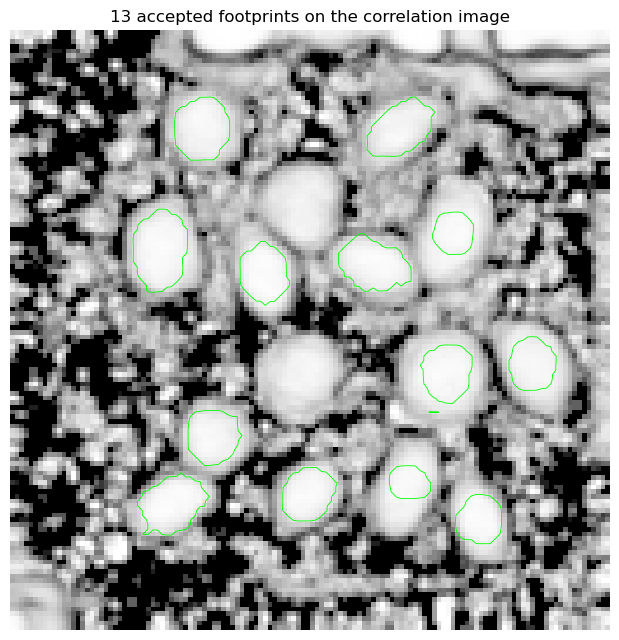

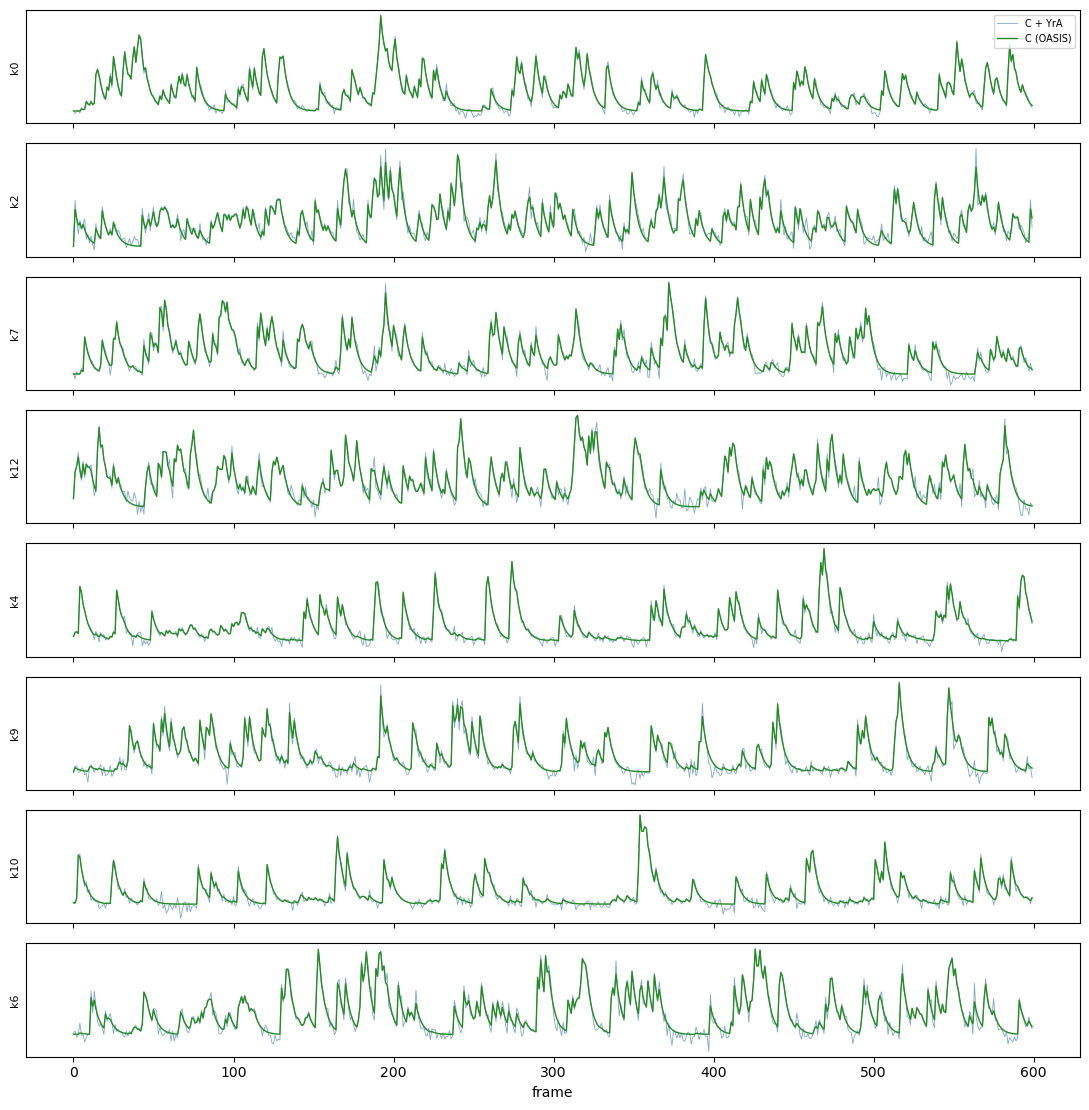

In [6]:
A_dense = np.asarray(model.A.todense()).reshape(H, W, -1)
acc = np.flatnonzero(model.accepted_mask)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(cn, cmap="gray")
for k in acc:
    fp = A_dense[..., k]
    if fp.max() > 0:
        ax.contour(fp, levels=[fp.max() * 0.3], colors="lime", linewidths=0.6)
ax.set_title(f"{len(acc)} accepted footprints on the correlation image"); ax.axis("off")
plt.tight_layout(); plt.show()

# A few of the strongest accepted traces: C (deconvolved) + C+YrA (shape-faithful).
if len(acc):
    top = acc[np.argsort(-model.C[acc].max(1))[:min(8, len(acc))]]
    C_proj = model.C + model.YrA
    fig, axes = plt.subplots(len(top), 1, figsize=(11, 1.4 * len(top)), sharex=True)
    for a, k in zip(np.atleast_1d(axes), top):
        a.plot(C_proj[k], lw=0.6, color="steelblue", alpha=0.7, label="C + YrA")
        a.plot(model.C[k], lw=1.0, color="forestgreen", label="C (OASIS)")
        a.set_yticks([]); a.set_ylabel(f"k{k}", fontsize=8)
    np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper right")
    plt.xlabel("frame"); plt.tight_layout(); plt.show()

## 6. Save

`model.save(OUTPUT_DIR)` writes `A`, `C`, `S`, `YrA`, the params, and the quality
mask. Reload anywhere with `CNMFe.load(OUTPUT_DIR)`.

In [7]:
model.save(OUTPUT_DIR)
print("results saved to", OUTPUT_DIR)

# Reload later and keep only the accepted components:
#   from minicnmfe import CNMFe
#   model = CNMFe.load(OUTPUT_DIR)
A_acc = model.A[:, model.accepted_mask]      # (H*W, n_accepted) footprints
C_acc = model.C[model.accepted_mask]         # (n_accepted, T)   deconvolved traces
S_acc = model.S[model.accepted_mask]         # (n_accepted, T)   spike trains
print("accepted:", A_acc.shape[1], "components")

results saved to /home/fs539/code/simpler_cnmfe/my_session_out
accepted: 13 components


## Where to go next

- **Parameters won't sit still?** Run the automated tuner: `python tune.py <session>`
  (or the `/tune-session` skill) — heuristics + an extraction sweep + validation,
  with a written report. See notebook **02** and `docs/tuning/`.
- **Long / dense / drifting recording?** Notebook **04** covers the production
  knobs: `global_bg_rank=1`, `nrg` footprint tightening, region cutouts, and
  downsample-once extraction.
- **60k+ frames?** The streaming path (used automatically above for big movies)
  keeps peak RAM bounded — see notebook **03** and `docs/getting-started/`.
- **Two flavours of the trace:** use `model.C` for clean spike timing and
  `model.C + model.YrA` for shape-faithful comparisons against an external signal.